In [1]:
# ============================
# CELL 1: COMMON DEFINITIONS
# ============================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
from google.colab import drive
drive.mount('/content/drive')
# ===========================
# Reproducibility
# ===========================
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# ==========================
# Device
# ==========================
if torch.cuda.is_available():
  device = 'cuda'
  print(torch.cuda.get_device_name(0))
else:
  device = 'cpu'
print('using device:', device)
# ==========================
# PINN Model
# ==========================
LAYERS = 8
NEURONS = 256
class PINN(nn.Module):
  def __init__(self, layers=LAYERS, neurons=NEURONS):
    super().__init__()
    net = [nn.Linear(3, neurons), nn.Tanh()]
    for _ in range(layers - 1):
      net += [nn.Linear(neurons, neurons), nn.Tanh()]
    net += [nn.Linear(neurons, 1)]
    self.net = nn.Sequential(*net)
    self.initialize_weights()

  def initialize_weights(self):
    for m in self.modules():
      if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
          nn.init.zeros_(m.bias)
  def forward(self, x):
    return self.net(x)
model = PINN().to(device)
# =========================
# Hyperparameters
# =========================
N_f = 10000
N_i = 5000
T_final = 2 * np.pi
adam_epochs = 20000
lbfgs_epochs = 500
w_pde, w_ic , w_eik = 1.0, 10.0, 1.0
# =========================
# Velocity Field
# =========================
def velocity_field(x, y):
  u = -(y - 0.5)
  v = (x - 0.5)
  return u, v
# =========================
# Initial Condition
# =========================
def initial_condition(x, y):
  xc, yc, r = 0.5, 0.75, 0.15
  return torch.sqrt((x - xc)**2 + (y - yc)**2) - r
# =========================
# Exact Solution
# =========================
def exact_solution(x, y, t):
  xc, yc, r = 0.5 - 0.25*np.sin(t), 0.5 + 0.25*np.cos(t), 0.15
  return torch.sqrt((x - xc)**2 + (y - yc)**2) - r
# =========================
# Sample Points
# =========================
torch.manual_seed(100)
torch.cuda.manual_seed(100)

X_f = torch.rand(N_f, 3, dtype=torch.float32, device=device).requires_grad_(True)

x_i = torch.rand(N_i, 1, dtype=torch.float32, device=device)
y_i = torch.rand(N_i, 1, dtype=torch.float32, device=device)
t_i = torch.zeros(N_i, 1, dtype=torch.float32, device=device)
X_i = torch.cat([x_i, y_i, t_i], dim=1)
# =========================
# Loss Function
# ========================
def physics_loss(X_f, X_i):
  # PDE Loss
  phi = model(X_f)
  grad_phi = torch.autograd.grad(phi, X_f, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
  phi_x, phi_y, phi_t = grad_phi[:, 0:1], grad_phi[:, 1:2], grad_phi[:, 2:3]
  u, v = velocity_field(X_f[:, 0:1], X_f[:, 1:2])
  f_pde = phi_t + T_final * (u * phi_x + v * phi_y)
  loss_pde = torch.mean(f_pde**2)
  # Initial Condition Loss
  phi_true = initial_condition(X_i[:, 0:1], X_i[:, 1:2])
  phi_pred = model(X_i)
  loss_ic = torch.mean((phi_true - phi_pred)**2)
  # Eikonal Loss
  norm_phi = torch.sqrt(phi_x**2 + phi_y**2 + 1e-8)
  loss_eik = torch.mean((norm_phi - 1)**2)

  total_loss = w_pde * loss_pde + w_ic * loss_ic + w_eik * loss_eik
  return loss_pde, loss_ic, loss_eik, total_loss

Mounted at /content/drive
using device: cpu


In [ ]:
# ========================
# Training
# ========================
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer_adam, step_size=1000, gamma=0.9)
start_time = time.time()
history = {'epoch': [], 'total': [], 'pde': [], 'ic': [], 'eik': []}
# Adam optimizer
for epoch in range(adam_epochs):
    optimizer_adam.zero_grad()
    loss_pde, loss_ic, loss_eik, loss = physics_loss(X_f, X_i)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer_adam.step()
    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    history['epoch'].append(epoch)
    history['total'].append(loss.item())
    history['pde'].append(loss_pde.item())
    history['ic'].append(loss_ic.item())
    history['eik'].append(loss_eik.item())

    if epoch % 2000 == 0:
      print(f"Adam Iter {epoch} | total loss {loss.item():.3e} | pde loss {loss_pde.item():.3e} | ic loss {loss_ic.item():.3e} | eik loss {loss_eik.item():.3e} | LR {lr:.3e}")
    elif epoch == adam_epochs - 1:
      print(f"Adam Iter {adam_epochs} | total loss {loss.item():.3e} | pde loss {loss_pde.item():.3e} | ic loss {loss_ic.item():.3e} | eik loss {loss_eik.item():.3e} | LR {lr:.3e}")

# LBFGS training
print("LBFGS Optimizer Starting...")
optimizer_lbfgs = optim.LBFGS(model.parameters(), lr=1.0,  line_search_fn='strong_wolfe')
loss_store = {}
for epoch in range(lbfgs_epochs):
    def closure():
        optimizer_lbfgs.zero_grad()
        loss_pde, loss_ic, loss_eik, loss = physics_loss(X_f, X_i)
        loss.backward()
        loss_store['total'] = loss.item()
        loss_store['pde'] = loss_pde.item()
        loss_store['ic'] = loss_ic.item()
        loss_store['eik'] = loss_eik.item()
        return loss
    optimizer_lbfgs.step(closure)

    history['epoch'].append(adam_epochs + epoch)
    history['total'].append(loss_store['total'])
    history['pde'].append(loss_store['pde'])
    history['ic'].append(loss_store['ic'])
    history['eik'].append(loss_store['eik'])
    if epoch % 200 == 0:
      print(f"LBFGS epoch {epoch} | total loss {loss_store['total']:.3e} | pde loss {loss_store['pde']:.3e} | ic loss {loss_store['ic']:.3e} | eik loss {loss_store['eik']:.3e}")
    elif epoch == lbfgs_epochs - 1:
      print(f"LBFGS epoch {lbfgs_epochs} | total loss {loss_store['total']:.3e} | pde loss {loss_store['pde']:.3e} | ic loss {loss_store['ic']:.3e} | eik loss {loss_store['eik']:.3e}")
end_time = time.time()
total_training_time = (end_time - start_time)/60
print(f"Full training done in {total_training_time:.1f} minutes")

# Save checkpoint
checkpoint_path = '/content/drive/MyDrive/RO_S1_exp05.pth'
torch.save({
    'model_state_dict':           model.state_dict(),
    'optimizer_adam_state_dict':  optimizer_adam.state_dict(),
    'optimizer_lbfgs_state_dict': optimizer_lbfgs.state_dict(),
    'training_time':              f'{total_training_time:.1f} minutes',
    'history':                    history
}, checkpoint_path)
print(f"Saved to {checkpoint_path}")

In [2]:
# ===========================
# Load Model
# ===========================
checkpoint = torch.load('/content/drive/MyDrive/RO_S1_exp05.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model Loaded Successfully!")

Model Loaded Successfully!


t = 0.00 | L2 Error = 1.8508e-04 | Mass Error = 5.5928e-05
t = 1.57 | L2 Error = 5.3975e-04 | Mass Error = 5.0335e-04
t = 4.71 | L2 Error = 8.6395e-04 | Mass Error = 8.2773e-04
t = 6.28 | L2 Error = 9.5720e-04 | Mass Error = 9.0603e-04
Average L2 Error   = 6.3650e-04
Average Mass Error = 5.7326e-04


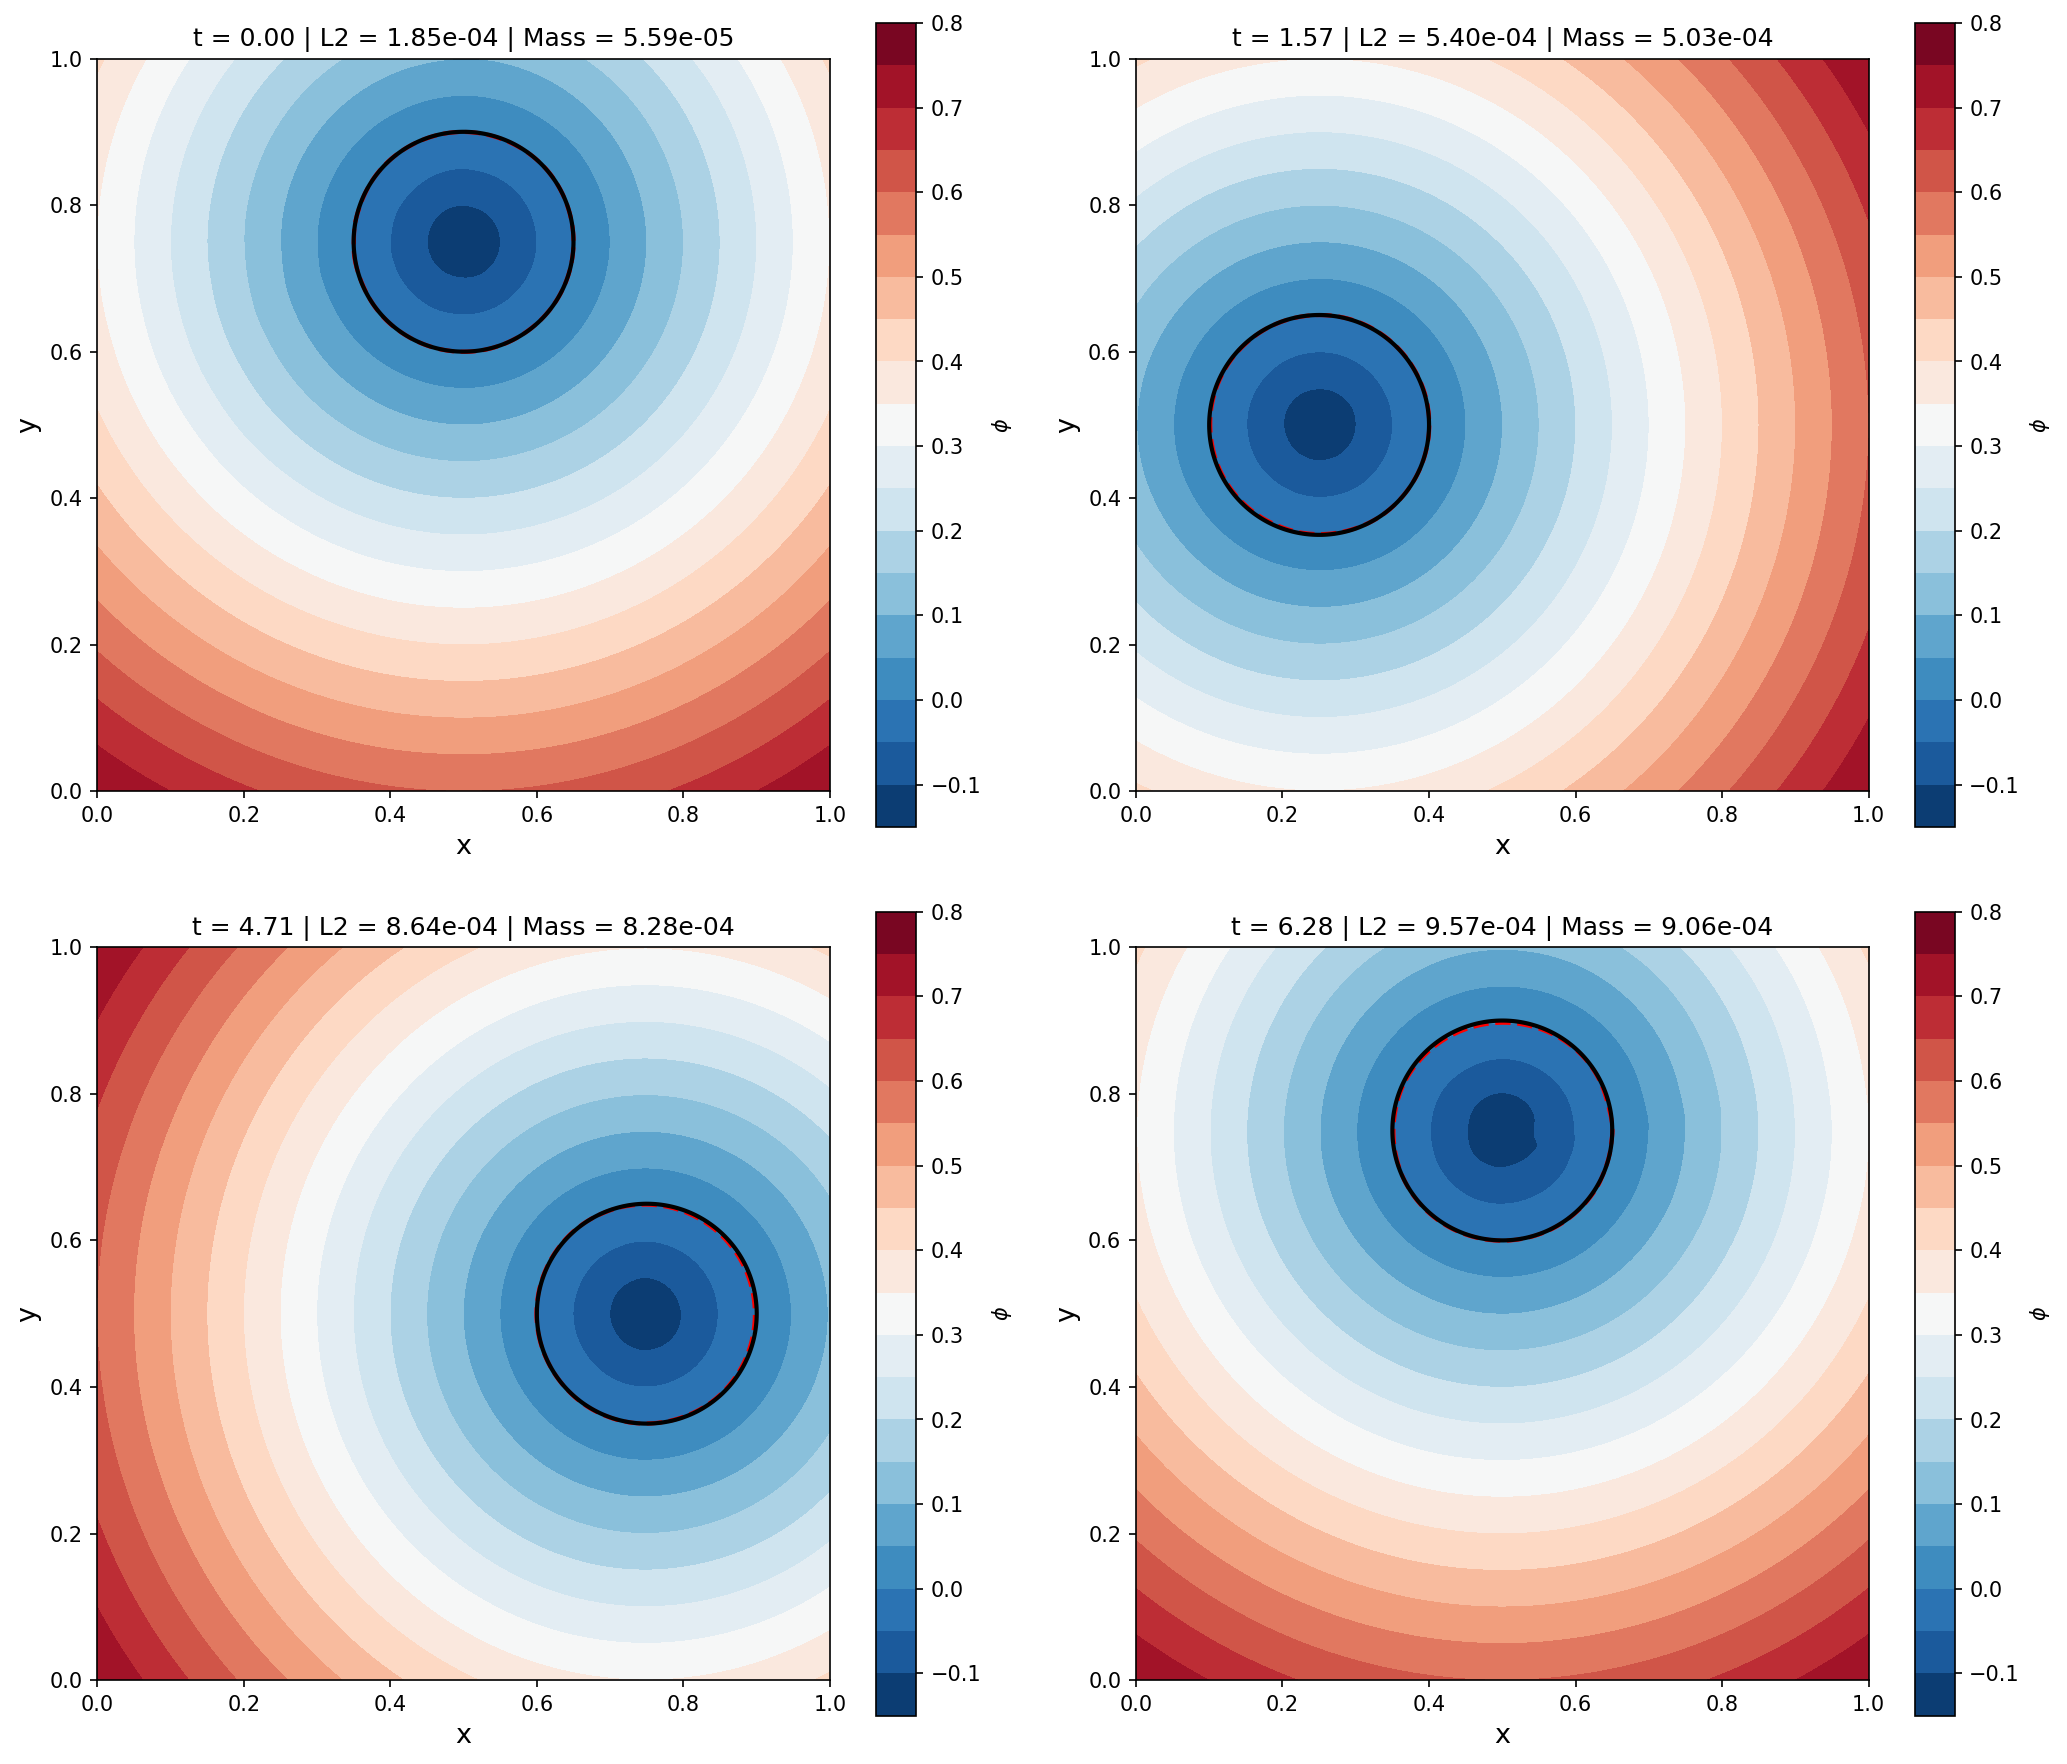

In [3]:
# ========================
# Evaluation
# ========================
import matplotlib.pyplot as plt

nx, ny = 300, 300
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x, y, indexing='ij')
dx = x[1] - x[0]
dy = y[1] - y[0]

times = [0.0, T_final/4, 3*T_final/4, T_final]
l2_errors = []
mass_errors = []

fig, axes = plt.subplots(2, 2, figsize=(14, 12), dpi=150)

for ax, t_val in zip(axes.flat, times):

    # normalize t for network input
    t_norm = t_val / T_final

    # build input tensor — network sees t_norm
    XYT = torch.tensor(
        np.stack([
            X.flatten(),
            Y.flatten(),
            t_norm * np.ones_like(X.flatten())
        ], axis=1),
        dtype=torch.float32,
        device=device
    )

    with torch.no_grad():
        phi_pred = model(XYT).cpu().numpy().reshape(nx, ny)

    # exact solution needs raw t_val, not t_norm
    x_tensor = torch.tensor(X.flatten(), dtype=torch.float32).reshape(-1, 1)
    y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32).reshape(-1, 1)
    phi_true = exact_solution(
        x_tensor,
        y_tensor,
        t_val
    ).numpy().reshape(nx, ny)

    # errors
    l2_error   = np.sqrt(np.mean((phi_pred - phi_true)**2))
    mass_pred  = np.sum(phi_pred < 0) * dx * dy
    mass_true  = np.sum(phi_true < 0) * dx * dy
    mass_error = abs(mass_pred - mass_true)

    l2_errors.append(l2_error)
    mass_errors.append(mass_error)

    print(f't = {t_val:.2f} | L2 Error = {l2_error:.4e} | Mass Error = {mass_error:.4e}')

    # plot predicted phi as filled contour
    countf = ax.contourf(X, Y, phi_pred, levels=20, cmap='RdBu_r')

    # plot both zero contours so you can see predicted vs true interface
    ax.contour(X, Y, phi_pred, levels=[0], colors='red',   linewidths=2,
               linestyles='--')                            # predicted interface
    ax.contour(X, Y, phi_true, levels=[0], colors='black', linewidths=2)
                                                           # true interface

    ax.set_title(f't = {t_val:.2f} | L2 = {l2_error:.2e} | Mass = {mass_error:.2e}')
    ax.set_xlabel('x', fontsize=13)
    ax.set_ylabel('y', fontsize=13)
    ax.set_aspect('equal')
    plt.colorbar(countf, ax=ax, label=r'$\phi$')

print(f'Average L2 Error   = {np.mean(l2_errors):.4e}')
print(f'Average Mass Error = {np.mean(mass_errors):.4e}')
plt.tight_layout()
plt.show()

In [4]:
import csv

# CONFIG
EXP_ID           = 'RO_S1_exp05'
BENCHMARK        = 'RO'
SAMPLING         = 'uniform'
SCHEDULER        = 'StepLR'
SCHEDULER_PARAMS = 'step_1000_gamma_0.9'
T_NORMALIZED     = True
CSV_PATH         = '/content/drive/MyDrive/RO_S1_scheduler_study.csv'

row = {
    'exp_id':           EXP_ID,
    'benchmark':        BENCHMARK,
    'N_f':              N_f,
    'N_i':              N_i,
    'layers':           LAYERS,
    'neurons':          NEURONS,
    'w_pde':            w_pde,
    'w_ic':             w_ic,
    'w_eik':            w_eik,
    'adam_epochs':      adam_epochs,
    'lbfgs_epochs':     lbfgs_epochs,
    'scheduler':        SCHEDULER,
    'scheduler_params': SCHEDULER_PARAMS,
    'sampling':         SAMPLING,
    't_normalized':     T_NORMALIZED,
    'L2_t0':            f'{l2_errors[0]:.4e}',
    'L2_tT':            f'{l2_errors[-1]:.4e}',
    'avg_L2':           f'{np.mean(l2_errors):.4e}',
    'mass_t0':          f'{mass_errors[0]:.4e}',
    'mass_tT':          f'{mass_errors[-1]:.4e}',
    'avg_mass':         f'{np.mean(mass_errors):.4e}',
    'training_time':    checkpoint['training_time']
}

with open(CSV_PATH, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=row.keys())
    if f.tell() == 0:
        writer.writeheader()
    writer.writerow(row)

print(f'Row appended → {CSV_PATH}')

Row appended → /content/drive/MyDrive/RO_S1_scheduler_study.csv
